# 05 — Tinh chỉnh và kiểm chứng

**Mục tiêu.** Lấy tổ hợp đã thắng ở giai đoạn 3 — **`xgboost` + `class_weight`** — tinh chỉnh
siêu tham số, rồi lần đầu tiên đưa nó ra **tập kiểm thử**. Từ đây mọi con số là con số báo cáo,
nên cái nào cũng phải kèm khoảng tin cậy, và phải qua hai phép thử khó hơn: chia theo thời gian
và rà soát rò rỉ.

**Việc tương ứng:** T-24 … T-28 trong [TASKS.md](../TASKS.md).

| Việc | Nội dung | Điều kiện xong |
|---|---|---|
| T-24 | `RandomizedSearchCV` 30 lần thử, `scoring='average_precision'` | bảng 5 cấu hình tốt nhất |
| T-25 | huấn luyện lại trên toàn tập train, đánh giá trên tập test | AC-M1 PR-AUC ≥ 0,75 và AC-M2 Recall ≥ 0,75 |
| T-26 | bootstrap 1.000 lần | mọi chỉ số chính có khoảng tin cậy (AC-M6) |
| T-27 | chia theo thời gian: ngày 1 train, ngày 2 test | bảng đối chiếu hai cách chia + giải thích (AC-M7) |
| T-28 | rà soát rò rỉ theo [08 §3.1](../docs/08-ke-hoach-kiem-thu.md) | 7 ô được tick, `test_no_leakage.py` xanh (AC-M4) |

**Quy tắc giữ nguyên từ các notebook trước.** Mọi lựa chọn — cấu hình thắng, ngưỡng τ\* — đều
làm trên tập huấn luyện (cross-validation hoặc out-of-fold). Tập kiểm thử chỉ được **đo**, không
được dùng để **chọn** (ML-06, ML-08). Phần so sánh với cấu hình mặc định trên tập test ở §3 là
để báo cáo, không phải để chọn lại.

**Sản phẩm bàn giao.** `reports/search_results.csv`, `reports/best_params.json`,
`reports/final_test_metrics.csv`, `reports/split_comparison.csv` và các hình `05_*`.

In [1]:
import json
import subprocess
import sys
import time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split

from src import plots
from src.config import DEFAULT_COST_FN, DEFAULT_COST_FP, RANDOM_STATE, REPORTS_DIR, TARGET
from src.data import SECONDS_PER_DAY, load_prepared, split_data, temporal_split
from src.evaluate import baseline_pr_auc, bootstrap_ci, bootstrap_diff, headline_metrics
from src.features import build_features
from src.modeling import (
    SEARCH_N_ITER,
    SEARCH_PARAMS,
    best_params_from,
    build_pipeline,
    imbalance_ratio,
    make_cv,
    oof_scores,
    run_search,
    search_table,
)
from src.threshold import NAIVE_THRESHOLD, metrics_at_threshold, pick_threshold

%matplotlib inline
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

np.random.seed(RANDOM_STATE)

# ---- Cấu hình -------------------------------------------------------------
DUONG_DAN_TIM_KIEM = REPORTS_DIR / "search_results.csv"
DUONG_DAN_THAM_SO = REPORTS_DIR / "best_params.json"
DUONG_DAN_LUOI = REPORTS_DIR / "grid_results.csv"

# Tìm kiếm 150 lần huấn luyện chạy ngoài notebook bằng scripts/run_search.py.
# Đặt True để chạy lại ngay trong notebook (khoảng 10-25 phút).
CHAY_LAI_TIM_KIEM = not DUONG_DAN_TIM_KIEM.exists()

CRITERION = "min_expected_cost"
N_BOOT = 1000
print(f"Chạy lại tìm kiếm trong notebook: {CHAY_LAI_TIM_KIEM}")

Chạy lại tìm kiếm trong notebook: False


---
## 1. Dữ liệu

Cách chia lặp lại đúng notebook 03 và 04 (`random_state=42`): cùng tập huấn luyện mà lưới 20 tổ
hợp đã thấy, cùng tập kiểm thử 95 gian lận đã lưu ở `data/test_set.parquet`.

In [2]:
df, _ = load_prepared()

X_train_tho, X_test_tho, y_train, y_test = split_data(df, as_features=False)
X_train = build_features(X_train_tho)
X_test = build_features(X_test_tho)

PHAN_TRAIN = len(y_train) / len(df)
PHAN_TEST = len(y_test) / len(df)

assert int(y_test.sum()) == 95, "tập kiểm thử phải trùng với notebook 03 (95 gian lận)"
assert not set(X_train_tho.index) & set(X_test_tho.index)

print()
print(f"Tập huấn luyện: {len(y_train):,} dòng, {int(y_train.sum())} gian lận "
      f"— tỷ lệ âm/dương {imbalance_ratio(y_train):.1f}")
print(f"Tập kiểm thử  : {len(y_test):,} dòng, {int(y_test.sum())} gian lận "
      f"— đường cơ sở PR-AUC {baseline_pr_auc(y_test):.5f}")

cv = make_cv(random_state=RANDOM_STATE)

Số dòng        : 284,807
Số cột         : 31
Ô thiếu giá trị: 0
Dòng trùng lặp : 1,081
Gian lận       : 492 (0.173%)
Không phát hiện vấn đề.


Loại 1,081 dòng trùng lặp (0.380%), trong đó 19 mẫu gian lận. Còn lại 283,726 dòng.



Tập huấn luyện: 226,980 dòng, 378 gian lận — tỷ lệ âm/dương 599.5
Tập kiểm thử  : 56,746 dòng, 95 gian lận — đường cơ sở PR-AUC 0.00167


---
## 2. Tinh chỉnh siêu tham số — T-24

Không gian tìm kiếm đúng bảng ở [04 §4](../docs/04-thiet-ke-mo-hinh-ml.md): 7 tham số, 30 lần
thử ngẫu nhiên, `StratifiedKFold(5)`, `scoring='average_precision'`, `random_state=42`.

Hai điều chỉnh nhỏ so với đặc tả, đều ghi lại ở docs/04 §4:

- **Giá trị lớn nhất của `scale_pos_weight` là 599,5 chứ không phải 578.** 578 là tỷ lệ âm/dương
  trên dữ liệu *thô*; sau khi loại trùng lặp và chia 80/20, tỷ lệ thật của tập huấn luyện là 599,5.
  Giá trị "cân bằng đầy đủ" phải khớp với dữ liệu mà mô hình thật sự học.
- **Song song ở tầng ngoài.** Tìm kiếm chạy `n_jobs=-1` còn XGBoost bên trong chạy một luồng:
  150 lần huấn luyện độc lập chia cho 12 lõi, thay vì 12 × 12 luồng tranh nhau.
  **Hệ quả cần biết:** XGBoost `hist` cộng dồn histogram theo thứ tự phụ thuộc số luồng, nên cùng
  một cấu hình chạy 1 luồng và 12 luồng cho điểm lệch nhau ở chữ số thứ ba–tư. Trên cùng một máy
  thì kết quả tái lập tuyệt đối; sang máy có số lõi khác thì có thể lệch nhẹ (xem docs/10, T-38).

Vì `scale_pos_weight = 1` nằm trong miền, tìm kiếm cũng tự trả lời lại câu hỏi của giai đoạn 3:
có cần xử lý mất cân bằng hay không.

In [3]:
if CHAY_LAI_TIM_KIEM:
    bat_dau = time.perf_counter()
    search = run_search(X_train, y_train, n_iter=SEARCH_N_ITER, cv=cv, refit=False,
                        random_state=RANDOM_STATE, verbose=1)
    bang_tk = search_table(search.cv_results_)
    bang_tk.to_csv(DUONG_DAN_TIM_KIEM, index=False, encoding="utf-8")
    print(f"tìm kiếm xong trong {(time.perf_counter() - bat_dau) / 60:.1f} phút")
else:
    bang_tk = pd.read_csv(DUONG_DAN_TIM_KIEM)
    thong_tin = json.loads(DUONG_DAN_THAM_SO.read_text(encoding="utf-8"))
    print(f"đọc lại {DUONG_DAN_TIM_KIEM.relative_to(ROOT)} — {len(bang_tk)} lần thử, "
          f"chạy mất {thong_tin['search_minutes']:.1f} phút bằng scripts/run_search.py")

assert len(bang_tk) == SEARCH_N_ITER, f"cần {SEARCH_N_ITER} lần thử, có {len(bang_tk)}"
assert bang_tk["pr_auc_mean"].max() < 0.95, "PR-AUC > 0,95 — dừng lại rà rò rỉ (08 §3.3)"

luoi = pd.read_csv(DUONG_DAN_LUOI)
mac_dinh_cv = luoi.query("model == 'xgboost' and strategy == 'class_weight'").iloc[0]
print(f"\nMốc từ giai đoạn 3 — xgboost + class_weight, cấu hình mặc định: "
      f"PR-AUC {mac_dinh_cv['pr_auc_mean']:.4f} ± {mac_dinh_cv['pr_auc_std']:.4f}")

đọc lại reports\search_results.csv — 30 lần thử, chạy mất 19.8 phút bằng scripts/run_search.py

Mốc từ giai đoạn 3 — xgboost + class_weight, cấu hình mặc định: PR-AUC 0.8549 ± 0.0301


In [4]:
# Bảng 5 cấu hình tốt nhất — sản phẩm của T-24
cot = ["rank", "pr_auc_mean", "pr_auc_std", "pr_auc_train", "overfit_gap",
       *SEARCH_PARAMS, "fit_seconds"]
top5 = bang_tk.head(5)[cot]
display(top5.style.format({
    "pr_auc_mean": "{:.4f}", "pr_auc_std": "±{:.4f}", "pr_auc_train": "{:.4f}",
    "overfit_gap": "{:.4f}", "learning_rate": "{:.4f}", "subsample": "{:.3f}",
    "colsample_bytree": "{:.3f}", "scale_pos_weight": "{:.0f}", "fit_seconds": "{:.1f}s",
}).background_gradient(subset=["pr_auc_mean"], cmap="Greens"))

dai_top5 = top5["pr_auc_mean"].max() - top5["pr_auc_mean"].min()
print(f"Dải PR-AUC của 5 cấu hình đầu : {dai_top5:.4f}")
print(f"Độ lệch chuẩn giữa các fold   : khoảng {top5['pr_auc_std'].mean():.4f}")
print(f"Hơn cấu hình mặc định (CV)    : {bang_tk.loc[0, 'pr_auc_mean'] - mac_dinh_cv['pr_auc_mean']:+.4f}")

,rank,pr_auc_mean,pr_auc_std,pr_auc_train,overfit_gap,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,scale_pos_weight,min_child_weight,fit_seconds
0,1,0.8538,±0.0328,1.0000,0.1462,750,6,0.0897,0.935,0.691,10,9,69.0s
1,2,0.8536,±0.0319,1.0000,0.1464,761,5,0.0539,0.902,0.649,600,1,135.7s
2,3,0.8532,±0.0322,1.0000,0.1468,602,7,0.0563,0.805,0.660,10,3,82.9s
3,4,0.8531,±0.0311,1.0000,0.1469,330,7,0.0477,0.623,0.640,10,4,50.9s
4,5,0.8530,±0.0289,0.9998,0.1467,676,6,0.0203,0.937,0.770,100,6,121.5s


Dải PR-AUC của 5 cấu hình đầu : 0.0008
Độ lệch chuẩn giữa các fold   : khoảng 0.0314
Hơn cấu hình mặc định (CV)    : -0.0010


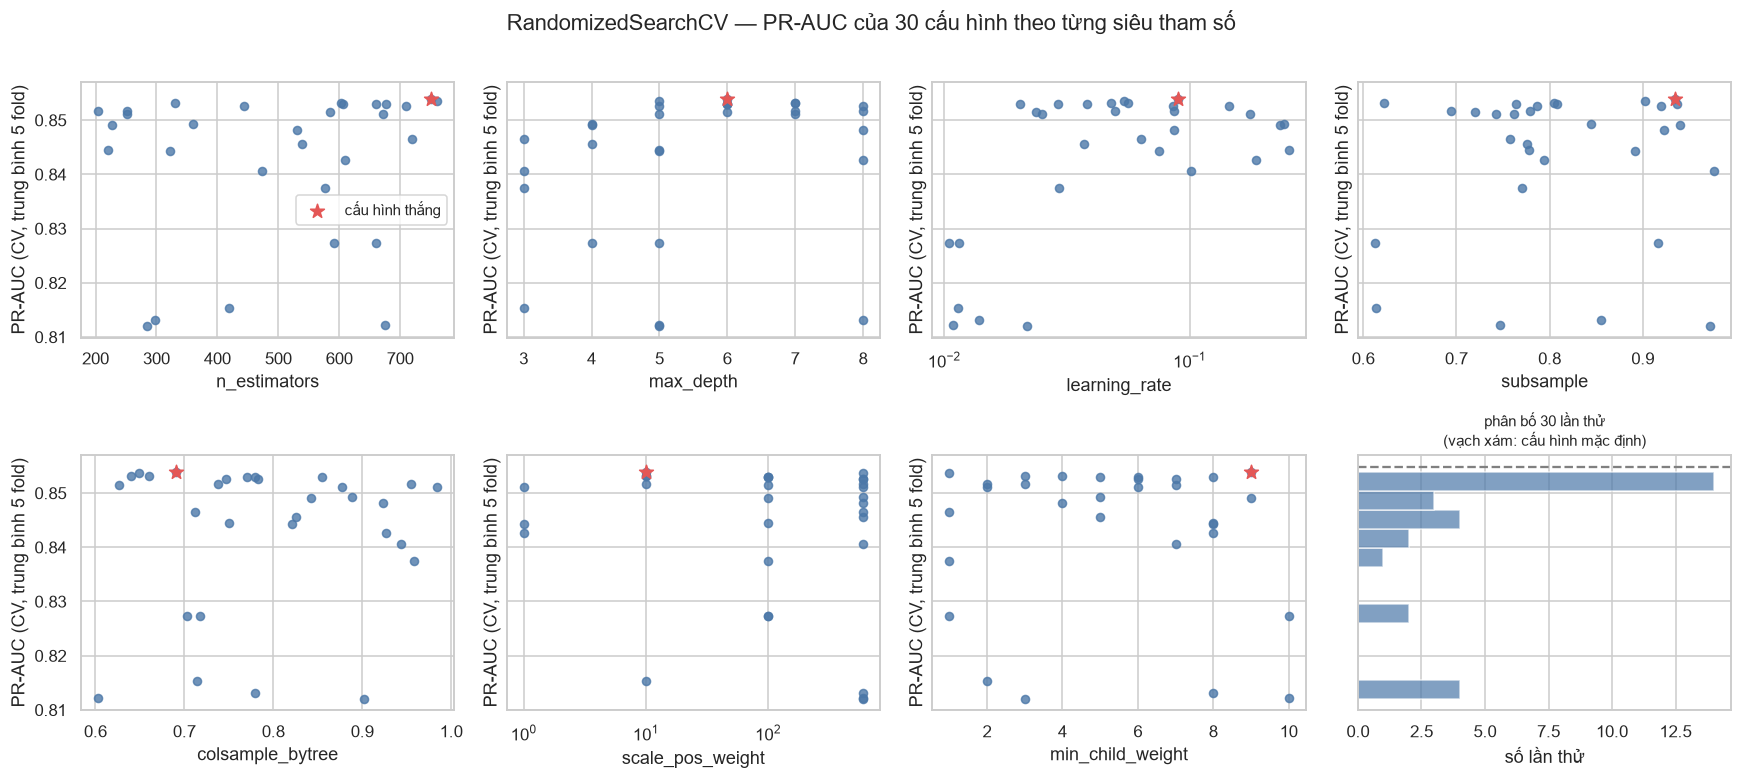

PR-AUC theo scale_pos_weight:


,số lần thử,mean,max
scale_pos_weight,,,
1.0,3,0.8460,0.8511
10.0,5,0.8454,0.8538
100.0,9,0.8440,0.8530
599.5,13,0.8407,0.8536


In [5]:
# 30 lần thử theo từng tham số: tham số nào thật sự quyết định PR-AUC?
fig, truc = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
for ax, ten in zip(truc.ravel(), SEARCH_PARAMS):
    ax.scatter(bang_tk[ten], bang_tk["pr_auc_mean"], s=28, c="#4C78A8", alpha=0.8)
    ax.scatter(bang_tk.loc[:0, ten], bang_tk.loc[:0, "pr_auc_mean"], s=90, c="#E45756",
               marker="*", label="cấu hình thắng")
    if ten in ("learning_rate", "scale_pos_weight"):
        ax.set_xscale("log")
    ax.set_xlabel(ten)
    ax.set_ylabel("PR-AUC (CV, trung bình 5 fold)")
ax = truc.ravel()[-1]
ax.axhline(mac_dinh_cv["pr_auc_mean"], c="grey", ls="--")
ax.hist(bang_tk["pr_auc_mean"], bins=12, orientation="horizontal", color="#4C78A8", alpha=0.7)
ax.set_xlabel("số lần thử")
ax.set_title("phân bố 30 lần thử\n(vạch xám: cấu hình mặc định)", fontsize=10)
truc.ravel()[0].legend(fontsize="small")
fig.suptitle("RandomizedSearchCV — PR-AUC của 30 cấu hình theo từng siêu tham số", y=1.01)
fig.tight_layout()
plots.save_fig(fig, "05_search_trials.png")
plt.show()

theo_spw = (bang_tk.groupby("scale_pos_weight")["pr_auc_mean"]
            .agg(["count", "mean", "max"]).rename(columns={"count": "số lần thử"}))
print("PR-AUC theo scale_pos_weight:")
display(theo_spw.round(4))

**Nhận xét T-24 — tinh chỉnh không vượt được cấu hình mặc định.**

- **Năm cấu hình đầu cách nhau 0,0008 PR-AUC**, trong khi độ lệch chuẩn giữa các fold là
  khoảng 0,031, tức lớn hơn gần 40 lần. Thứ hạng 1–5 trong bảng trên chỉ là nhiễu, không có
  nghĩa gì. Bảng được giữ lại vì T-24 yêu cầu, không phải vì dòng đầu thật sự tốt nhất.
- **Cấu hình đứng đầu (0,8538) còn thấp hơn cấu hình mặc định của giai đoạn 3 (0,8549).** Cấu
  hình mặc định (`n_estimators=500, max_depth=6, learning_rate=0,05`) vốn đã nằm giữa vùng tốt
  của không gian tìm kiếm; 30 lần thử ngẫu nhiên không tìm được gì hơn nó. Đây là kết quả âm
  tính, và được báo cáo đúng như vậy.
- **Trần nằm ở dữ liệu, không nằm ở siêu tham số.** Quá nửa số lần thử có `pr_auc_train` ≈ 1,00
  (trung vị 0,9999) và `overfit_gap` trung vị 0,147. XGBoost học thuộc gần hết các mẫu gian lận
  của mỗi fold huấn luyện, còn khoảng 15% PR-AUC mất ở fold validation là những vụ mà 31 đặc
  trưng không tách được khỏi giao dịch hợp lệ. Tinh chỉnh độ sâu hay tốc độ học không tạo thêm
  thông tin cho những vụ đó. Các cấu hình ít khớp hơn (`pr_auc_train` thấp nhất 0,879) cũng không
  tốt hơn ở validation.
- **`scale_pos_weight` gần như không quan trọng.** Trung bình PR-AUC theo bốn mức 1 / 10 / 100 /
  599,5 lần lượt là 0,846 / 0,845 / 0,844 / 0,841; ba mức 10, 100 và 599,5 đều có mặt trong
  nhóm 5 đầu, còn mức 1 (không cân bằng) có lần thử tốt nhất 0,851, chỉ kém nhóm đầu 0,003.
  Điều này khớp với phát hiện của giai đoạn 3 (`xgboost + none` chỉ kém `class_weight` 0,0035):
  với mô hình boosting, trọng số lớp chủ yếu **dịch điểm rủi ro** chứ không đổi **thứ tự xếp
  hạng**, mà PR-AUC chỉ đo thứ tự. Tác động thật của nó sẽ hiện ra ở giai đoạn 5, khi chọn ngưỡng.

---
## 3. Huấn luyện lại trên toàn tập train, đánh giá trên tập test — T-25

Ba bước, đúng thứ tự:

1. **Điểm out-of-fold** của cấu hình thắng trên tập huấn luyện → chọn **τ\*** cực tiểu chi phí
   (`cost_fn = 122,21`, `cost_fp = 5,00`). Ngưỡng chốt ở đây, trước khi nhìn tập kiểm thử (ML-08).
2. **Huấn luyện lại** cấu hình thắng trên toàn bộ 226.980 dòng huấn luyện.
3. **Chấm tập kiểm thử một lần**, đo tại τ\* đã chốt.

AC-M2 đòi Recall ≥ 0,75 **tại ngưỡng đề xuất**, tức τ\*, không phải τ = 0,5. Cả hai đều được
báo cáo để thấy khoảng cách.

Để biết tinh chỉnh có đáng công không, cấu hình **mặc định** của giai đoạn 3 cũng đi qua đúng ba
bước ấy. Điểm out-of-fold của nó đã có sẵn trong `grid_results.npz`, không cần huấn luyện lại.

In [6]:
THAM_SO_TOT = best_params_from(bang_tk)
print("Cấu hình thắng:", json.dumps(THAM_SO_TOT, indent=None))

# Bước 1 — điểm out-of-fold → τ*
bat_dau = time.perf_counter()
oof_tot = oof_scores(build_pipeline("xgboost", "class_weight", y=y_train, **THAM_SO_TOT),
                     X_train, y_train, cv=cv)
print(f"điểm out-of-fold: {time.perf_counter() - bat_dau:.0f}s, "
      f"PR-AUC OOF {average_precision_score(y_train, oof_tot):.4f}")

with np.load(DUONG_DAN_LUOI.with_suffix(".npz")) as npz:
    oof_mac_dinh = npz["xgboost__class_weight"]

kw_nguong = dict(cost_fn=DEFAULT_COST_FN, cost_fp=DEFAULT_COST_FP, sample_fraction=PHAN_TRAIN)
tau_tot = pick_threshold(y_train, oof_tot, CRITERION, **kw_nguong)
tau_mac_dinh = pick_threshold(y_train, oof_mac_dinh, CRITERION, **kw_nguong)
print(f"τ* (chọn trên OOF của tập huấn luyện): tinh chỉnh {tau_tot:.4f}, mặc định {tau_mac_dinh:.4f}")

Cấu hình thắng: {"n_estimators": 750, "max_depth": 6, "learning_rate": 0.0897425574385695, "subsample": 0.9350840423629312, "colsample_bytree": 0.6905983100791752, "scale_pos_weight": 10.0, "min_child_weight": 9}


điểm out-of-fold: 56s, PR-AUC OOF 0.8526
τ* (chọn trên OOF của tập huấn luyện): tinh chỉnh 0.0600, mặc định 0.0232


### 3.1 Chọn cấu hình — trên tập huấn luyện, trước khi nhìn tập test

Quy tắc chốt **trước** khi chấm tập kiểm thử: cấu hình tinh chỉnh chỉ thay cấu hình mặc định nếu
bootstrap hiệu PR-AUC **theo cặp trên điểm out-of-fold** (04 §5.4) cho khoảng tin cậy **không chứa
0**. Nếu chứa 0 thì hai cấu hình hoà, và giữ cấu hình mặc định: nó đã được kiểm chứng ở giai
đoạn 3, dùng ít cây hơn và không mang theo rủi ro "thắng nhờ may" của việc chọn cực đại trong 30
lần thử.

In [7]:
hieu_oof = bootstrap_diff(y_train, oof_tot, oof_mac_dinh, n_boot=N_BOOT, random_state=RANDOM_STATE)
print(f"PR-AUC OOF: tinh chỉnh {average_precision_score(y_train, oof_tot):.4f}, "
      f"mặc định {average_precision_score(y_train, oof_mac_dinh):.4f}")
print(f"Hiệu tinh chỉnh − mặc định trên OOF: {hieu_oof['value']:+.4f} "
      f"[{hieu_oof['ci_low']:+.4f}, {hieu_oof['ci_high']:+.4f}], tinh chỉnh thắng ở "
      f"{hieu_oof['a_wins']:.0%} số lần lặp")

CHON = "tinh chỉnh" if hieu_oof["ci_low"] > 0 else "mặc định"
THAM_SO_CHON = THAM_SO_TOT if CHON == "tinh chỉnh" else {}
OOF_CHON = oof_tot if CHON == "tinh chỉnh" else oof_mac_dinh
print()
print(f"→ Cấu hình được chọn: {CHON.upper()}  "
      f"({'khoảng tin cậy không chứa 0' if CHON == 'tinh chỉnh' else 'khoảng tin cậy chứa 0, hai cấu hình hoà'})")

PR-AUC OOF: tinh chỉnh 0.8526, mặc định 0.8532
Hiệu tinh chỉnh − mặc định trên OOF: -0.0006 [-0.0087, +0.0072], tinh chỉnh thắng ở 45% số lần lặp

→ Cấu hình được chọn: MẶC ĐỊNH  (khoảng tin cậy chứa 0, hai cấu hình hoà)


In [8]:
# Bước 2 và 3 — huấn luyện lại trên toàn tập train, chấm tập test một lần
mo_hinh = {}
diem_test = {}
for ten, tham_so in (("tinh chỉnh", THAM_SO_TOT), ("mặc định", {})):
    pipe = build_pipeline("xgboost", "class_weight", y=y_train, **tham_so)
    bat_dau = time.perf_counter()
    pipe.fit(X_train, y_train)
    mo_hinh[ten] = pipe
    diem_test[ten] = pipe.predict_proba(X_test)[:, 1]
    print(f"{ten:10s}: huấn luyện {time.perf_counter() - bat_dau:5.1f}s, "
          f"{np.unique(diem_test[ten]).size:,} điểm rủi ro khác nhau trên tập test")

nguong = {"tinh chỉnh": tau_tot, "mặc định": tau_mac_dinh}
kw_test = dict(cost_fn=DEFAULT_COST_FN, cost_fp=DEFAULT_COST_FP, sample_fraction=PHAN_TEST)

hang = []
for ten, s in diem_test.items():
    for nhan, tau in (("τ*", nguong[ten]), ("0,5", NAIVE_THRESHOLD)):
        m = metrics_at_threshold(y_test, s, tau, **kw_test)
        hang.append({"cấu hình": ten, "ngưỡng": nhan, "τ": tau,
                     "PR-AUC": average_precision_score(y_test, s),
                     "recall": m.recall, "precision": m.precision, "F1": m.f1,
                     "TP": m.tp, "FP": m.fp, "FN": m.fn,
                     "cảnh báo/ngày": m.alerts_per_day, "chi phí": m.expected_cost})
bang_test = pd.DataFrame(hang)
display(bang_test.style.format({
    "τ": "{:.4f}", "PR-AUC": "{:.4f}", "recall": "{:.3f}", "precision": "{:.3f}",
    "F1": "{:.3f}", "cảnh báo/ngày": "{:,.0f}", "chi phí": "{:,.0f} USD"}).hide(axis="index"))

tinh chỉnh: huấn luyện  13.9s, 56,144 điểm rủi ro khác nhau trên tập test


mặc định  : huấn luyện  11.5s, 56,204 điểm rủi ro khác nhau trên tập test


cấu hình,ngưỡng,τ,PR-AUC,recall,precision,F1,TP,FP,FN,cảnh báo/ngày,chi phí
tinh chỉnh,τ*,0.0600,0.8186,0.800,0.738,0.768,76,27,19,257,"2,457 USD"
tinh chỉnh,"0,5",0.5000,0.8186,0.758,0.973,0.852,72,2,23,185,"2,821 USD"
mặc định,τ*,0.0232,0.8252,0.811,0.670,0.733,77,38,18,287,"2,390 USD"
mặc định,"0,5",0.5000,0.8252,0.779,0.949,0.855,74,4,21,195,"2,586 USD"


In [9]:
# Nghiệm thu AC-M1 và AC-M2 trên cấu hình được chọn ở §3.1 (không chọn lại theo tập test)
chon = bang_test.query("`cấu hình` == @CHON and `ngưỡng` == 'τ*'").iloc[0]
print(f"Cấu hình được chọn ở §3.1: {CHON}")
ac_m1 = chon["PR-AUC"] >= 0.75
ac_m2 = chon["recall"] >= 0.75
print(f"AC-M1  PR-AUC trên tập test = {chon['PR-AUC']:.4f}  (≥ 0,75)  → {'ĐẠT' if ac_m1 else 'KHÔNG ĐẠT'}")
print(f"AC-M2  Recall tại τ* = {chon['recall']:.4f} ({int(chon['TP'])}/95)  (≥ 0,75)  "
      f"→ {'ĐẠT' if ac_m2 else 'KHÔNG ĐẠT'}")
assert ac_m1 and ac_m2, "T-25 chưa đạt — không tick"

# Tinh chỉnh có hơn mặc định thật không? Bootstrap theo cặp trên tập test (04 §5.4)
hieu = bootstrap_diff(y_test, diem_test["tinh chỉnh"], diem_test["mặc định"],
                      n_boot=N_BOOT, random_state=RANDOM_STATE)
print(f"\nHiệu PR-AUC tinh chỉnh − mặc định trên tập test: {hieu['value']:+.4f} "
      f"[{hieu['ci_low']:+.4f}, {hieu['ci_high']:+.4f}]; tinh chỉnh thắng ở "
      f"{hieu['a_wins']:.0%} số lần lặp; khoảng tin cậy chứa 0: {hieu['contains_zero']}")

Cấu hình được chọn ở §3.1: mặc định
AC-M1  PR-AUC trên tập test = 0.8252  (≥ 0,75)  → ĐẠT
AC-M2  Recall tại τ* = 0.8105 (77/95)  (≥ 0,75)  → ĐẠT



Hiệu PR-AUC tinh chỉnh − mặc định trên tập test: -0.0066 [-0.0285, +0.0126]; tinh chỉnh thắng ở 26% số lần lặp; khoảng tin cậy chứa 0: True


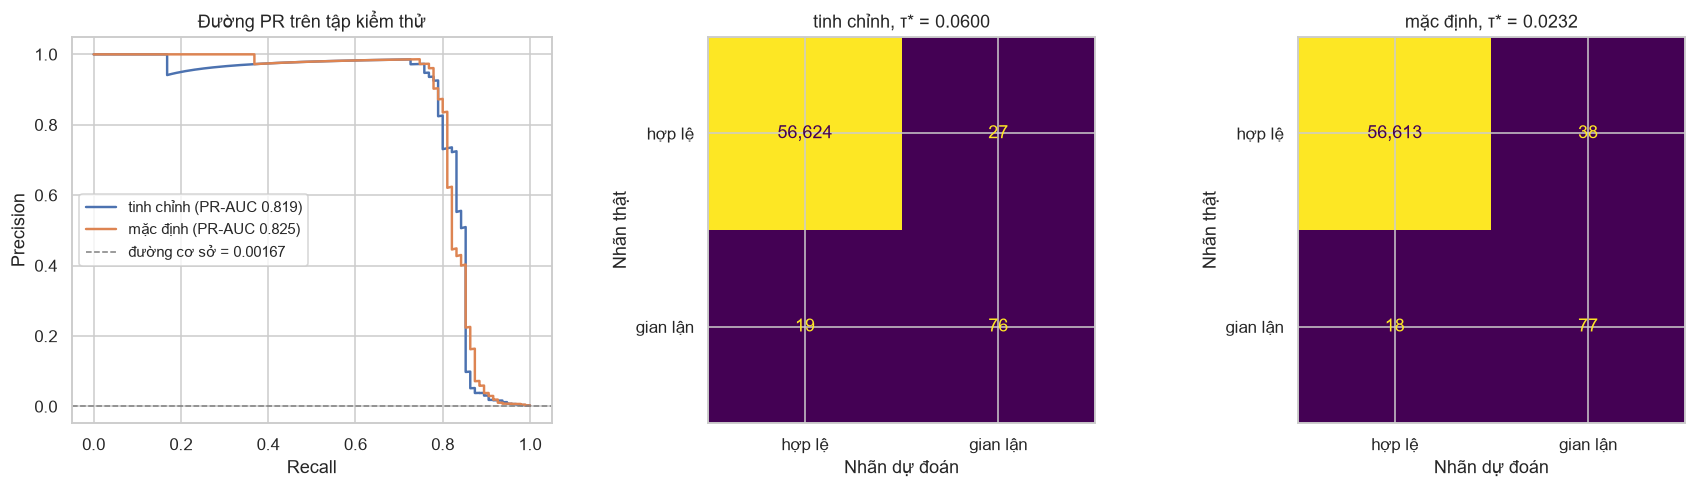

In [10]:
fig, truc = plt.subplots(1, 3, figsize=(16, 4.6))
plots.plot_pr_curves({f"{k} (PR-AUC {average_precision_score(y_test, v):.3f})": v
                      for k, v in diem_test.items()}, y_true=y_test, ax=truc[0])
truc[0].set_title("Đường PR trên tập kiểm thử")
for ten, ax in zip(("tinh chỉnh", "mặc định"), truc[1:]):
    plots.plot_confusion(y_test, (diem_test[ten] >= nguong[ten]).astype(int), ax=ax)
    ax.set_title(f"{ten}, τ* = {nguong[ten]:.4f}")
fig.tight_layout()
plots.save_fig(fig, "05_test_pr_and_confusion.png")
plt.show()

**Nhận xét T-25 — AC-M1 và AC-M2 đều đạt, với cấu hình mặc định.**

- **Chọn cấu hình.** Trên điểm out-of-fold, hiệu PR-AUC tinh chỉnh − mặc định là −0,0006
  [−0,0087, +0,0072]: khoảng tin cậy chứa 0, tinh chỉnh chỉ thắng 45% số lần lặp. Theo quy tắc
  đặt trước ở §3.1, **giữ cấu hình mặc định**. Quyết định này làm trên tập huấn luyện; tập kiểm
  thử sau đó xác nhận chứ không đảo lại nó (−0,0066 [−0,0285, +0,0126], cũng chứa 0).
- **AC-M1:** PR-AUC trên tập kiểm thử **0,825**, gấp 494 lần đường cơ sở 0,00167.
- **AC-M2:** tại τ\* = 0,0232 (chọn trên out-of-fold), recall **0,811** — bắt 77/95 vụ, đổi lại 38
  cảnh báo giả, precision 0,670. Chi phí kỳ vọng 2.390 USD, thấp nhất trong bảng.
- **Ngưỡng 0,5 bỏ lọt thêm 3 vụ.** Ở τ = 0,5, recall 0,779 (74/95), chi phí 2.586 USD. Khoảng
  cách còn nhỏ vì XGBoost `class_weight` đã đẩy điểm của lớp dương lên; phân tích đầy đủ bốn
  phương án ngưỡng là việc của T-29/T-30.
- **PR-AUC test (0,825) thấp hơn out-of-fold (0,853) 0,028** — nằm gọn trong khoảng tin cậy
  [0,747 – 0,896] ở §4, và nhỏ hơn độ lệch chuẩn giữa các fold. Không có dấu hiệu quá khớp vào
  quá trình chọn mô hình.
- **Hai cấu hình khác nhau ở ngưỡng, không ở xếp hạng.** Cấu hình tinh chỉnh (`scale_pos_weight=10`)
  có τ\* = 0,060, cao hơn gần 3 lần, và tại đó precision cao hơn (0,738 so với 0,670) còn recall
  thấp hơn một vụ. Đây là cùng một đường PR, đứng ở hai điểm khác nhau — minh hoạ trước cho luận
  điểm của giai đoạn 5 rằng **ngưỡng quan trọng hơn siêu tham số**.

---
## 4. Khoảng tin cậy bootstrap — T-26

Tập kiểm thử chỉ có **95** gian lận: một vụ bắt thêm hay bỏ lọt đã làm recall nhảy 1,05 điểm
phần trăm. Mọi chỉ số chính vì thế đi kèm khoảng tin cậy 95% từ **bootstrap phân tầng 1.000 lần**
(04 §5.3): lấy mẫu lại riêng trong từng lớp để lần lặp nào cũng giữ đúng 95 mẫu dương.

Precision, recall, F1 đo tại τ\* **cố định** — ngưỡng không được dò lại trong từng lần lặp, vì
ngoài đời ngưỡng cũng chỉ chọn một lần.

In [11]:
hang_ci = []
chi_so_chinh = {}
for ten, s in diem_test.items():
    hm = headline_metrics(y_test, s, nguong[ten], n_boot=N_BOOT, random_state=RANDOM_STATE)
    hm["f1"] = bootstrap_ci(y_test, s, "f1", threshold=nguong[ten], n_boot=N_BOOT,
                            random_state=RANDOM_STATE)
    chi_so_chinh[ten] = hm
    for chi_so in ("pr_auc", "roc_auc", "recall", "precision", "f1"):
        r = hm[chi_so]
        hang_ci.append({"cấu hình": ten, "chỉ số": chi_so, "giá trị": r["value"],
                        "ci_low": r["ci_low"], "ci_high": r["ci_high"],
                        "độ rộng": r["ci_high"] - r["ci_low"], "threshold": nguong[ten]})

bang_ci = pd.DataFrame(hang_ci)
bang_ci.to_csv(REPORTS_DIR / "final_test_metrics.csv", index=False, encoding="utf-8")

hien = bang_ci.assign(**{"trình bày": bang_ci.apply(
    lambda r: f"{r['giá trị']:.3f} [{r['ci_low']:.3f} – {r['ci_high']:.3f}]", axis=1)})
display(hien.pivot(index="chỉ số", columns="cấu hình", values="trình bày")
        .reindex(["pr_auc", "roc_auc", "recall", "precision", "f1"]))
print(f"đã ghi reports/final_test_metrics.csv — {len(bang_ci)} dòng, mỗi dòng có khoảng tin cậy")

assert bang_ci[["ci_low", "ci_high"]].notna().all().all()
assert (bang_ci["ci_low"] <= bang_ci["giá trị"]).all() and (bang_ci["giá trị"] <= bang_ci["ci_high"]).all()

cấu hình,mặc định,tinh chỉnh
chỉ số,,
pr_auc,0.825 [0.747 – 0.896],0.819 [0.736 – 0.893]
roc_auc,0.977 [0.961 – 0.991],0.976 [0.957 – 0.991]
recall,0.811 [0.737 – 0.884],0.800 [0.716 – 0.874]
precision,0.670 [0.600 – 0.752],0.738 [0.664 – 0.815]
f1,0.733 [0.675 – 0.792],0.768 [0.701 – 0.828]


đã ghi reports/final_test_metrics.csv — 10 dòng, mỗi dòng có khoảng tin cậy


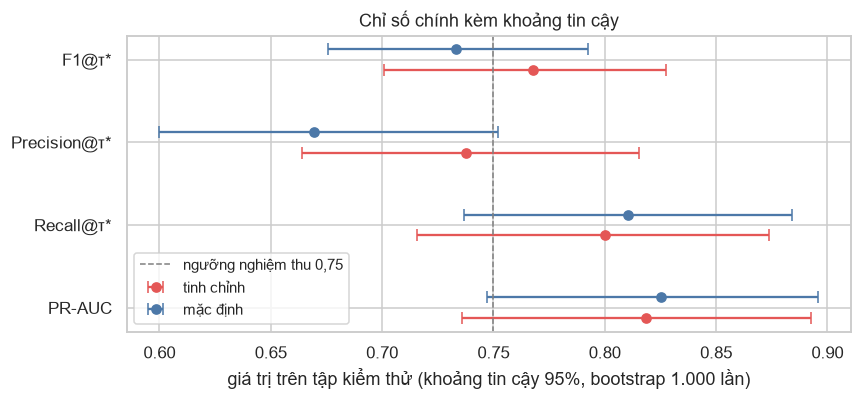

In [12]:
fig, ax = plt.subplots(figsize=(8, 3.8))
chi_so_ve = ["pr_auc", "recall", "precision", "f1"]
for i, (ten, mau) in enumerate((("tinh chỉnh", "#E45756"), ("mặc định", "#4C78A8"))):
    con = bang_ci[bang_ci["cấu hình"] == ten].set_index("chỉ số").loc[chi_so_ve]
    y = np.arange(len(chi_so_ve)) + (i - 0.5) * 0.25
    ax.errorbar(con["giá trị"], y, xerr=[con["giá trị"] - con["ci_low"], con["ci_high"] - con["giá trị"]],
                fmt="o", color=mau, capsize=4, label=ten)
ax.axvline(0.75, color="grey", ls="--", lw=1, label="ngưỡng nghiệm thu 0,75")
ax.set_yticks(range(len(chi_so_ve)), ["PR-AUC", "Recall@τ*", "Precision@τ*", "F1@τ*"])
ax.set_xlabel("giá trị trên tập kiểm thử (khoảng tin cậy 95%, bootstrap 1.000 lần)")
ax.set_title("Chỉ số chính kèm khoảng tin cậy")
ax.legend(fontsize="small", loc="lower left")
fig.tight_layout()
plots.save_fig(fig, "05_bootstrap_ci.png")
plt.show()

**Nhận xét T-26 — khoảng tin cậy rộng, và cả hai tiêu chí nghiệm thu đều sát cận dưới.**

| Chỉ số (cấu hình mặc định, τ\* = 0,0232) | Giá trị [KTC 95%] |
|---|---|
| PR-AUC | 0,825 [0,747 – 0,896] |
| ROC-AUC | 0,977 [0,961 – 0,991] |
| Recall@τ\* | 0,811 [0,737 – 0,884] |
| Precision@τ\* | 0,670 [0,600 – 0,752] |
| F1@τ\* | 0,733 [0,675 – 0,792] |

- **Khoảng tin cậy của PR-AUC rộng 0,15**, của recall rộng 0,15. Đó là cái giá của 95 mẫu dương
  và là con số phải đi kèm mọi tuyên bố trong báo cáo.
- **Cận dưới của cả PR-AUC (0,747) và recall (0,737) đều nằm ngay dưới 0,75.** AC-M1 và AC-M2
  đạt theo *ước lượng điểm*, nhưng không đạt "một cách chắc chắn": với một tập kiểm thử khác cùng
  kích thước, khả năng rơi xuống dưới ngưỡng nghiệm thu là có thật. Báo cáo phải nói đúng như vậy.
- **ROC-AUC 0,977 so với PR-AUC 0,825** — lại một lần nữa ROC tô hồng bức tranh (04 §5.2).
- **Hai cấu hình chồng lấn nhau ở mọi chỉ số**, khớp với kết luận "hoà" ở §3.1.

---
## 5. Chia theo thời gian — T-27

Chia ngẫu nhiên trộn giao dịch của hai ngày vào cả hai tập: mô hình được "xem trước" hành vi
của chính ngày mà nó sẽ bị chấm. Triển khai thật không bao giờ như vậy — mô hình học từ quá khứ
rồi chấm tương lai. `temporal_split()` mô phỏng điều đó: **ngày 1** (`Time < 86.400`) huấn luyện,
**ngày 2** kiểm thử (FR-10).

Hai cách chia khác nhau ở **hai** chỗ cùng lúc, nên so thẳng thì không biết phần chênh đến từ
đâu:

- **lượng dữ liệu huấn luyện** — ngày 1 chỉ có khoảng một nửa dữ liệu, so với 80% ở cách ngẫu nhiên;
- **độ lệch thời gian** — tập kiểm thử là một ngày mô hình chưa từng thấy.

Vì vậy thêm một **đối chứng**: chia ngẫu nhiên nhưng *thu nhỏ* tập huấn luyện về đúng kích thước
ngày 1, chấm trên cùng tập kiểm thử ngẫu nhiên. Chênh giữa đối chứng và ngẫu nhiên đầy đủ là phần
do lượng dữ liệu; chênh giữa đối chứng và theo thời gian là phần do độ lệch thời gian.

Cả ba cách dùng cùng cấu hình được chọn ở §3.1 và cùng quy tắc: τ\* chọn trên out-of-fold của **chính
tập huấn luyện của cách chia đó**.

In [13]:
X_n1_tho, X_n2_tho, y_n1, y_n2 = temporal_split(df, as_features=False)
X_n1, X_n2 = build_features(X_n1_tho), build_features(X_n2_tho)

mo_ta = pd.DataFrame({
    "số dòng": [len(y_n1), len(y_n2)],
    "gian lận": [int(y_n1.sum()), int(y_n2.sum())],
    "tỷ lệ gian lận": [y_n1.mean(), y_n2.mean()],
    "Amount trung vị (gian lận)": [X_n1_tho.loc[y_n1 == 1, "Amount"].median(),
                                   X_n2_tho.loc[y_n2 == 1, "Amount"].median()],
}, index=["ngày 1 (train)", "ngày 2 (test)"])
display(mo_ta.style.format({"số dòng": "{:,}", "tỷ lệ gian lận": "{:.4%}",
                            "Amount trung vị (gian lận)": "{:.2f}"}))
assert len(y_n1) + len(y_n2) == len(df)
assert X_n1_tho["Time"].max() < SECONDS_PER_DAY <= X_n2_tho["Time"].min()

,số dòng,gian lận,tỷ lệ gian lận,Amount trung vị (gian lận)
ngày 1 (train),"144,236",272,0.1886%,11.85
ngày 2 (test),"139,490",201,0.1441%,8.90


In [14]:
def danh_gia_cach_chia(ten, X_tr, y_tr, X_te, y_te, phan_train, phan_test):
    '''Một cách chia: OOF → τ*, huấn luyện lại, chấm tập kiểm thử, kèm khoảng tin cậy.'''
    pipe = build_pipeline("xgboost", "class_weight", y=y_tr, **THAM_SO_CHON)
    oof = oof_scores(pipe, X_tr, y_tr, cv=make_cv(random_state=RANDOM_STATE))
    tau = pick_threshold(y_tr, oof, CRITERION, cost_fn=DEFAULT_COST_FN,
                         cost_fp=DEFAULT_COST_FP, sample_fraction=phan_train)
    s = pipe.fit(X_tr, y_tr).predict_proba(X_te)[:, 1]
    m = metrics_at_threshold(y_te, s, tau, cost_fn=DEFAULT_COST_FN, cost_fp=DEFAULT_COST_FP,
                             sample_fraction=phan_test)
    pr = bootstrap_ci(y_te, s, "pr_auc", n_boot=N_BOOT, random_state=RANDOM_STATE)
    rc = bootstrap_ci(y_te, s, "recall", threshold=tau, n_boot=N_BOOT, random_state=RANDOM_STATE)
    pc = bootstrap_ci(y_te, s, "precision", threshold=tau, n_boot=N_BOOT, random_state=RANDOM_STATE)
    return {
        "cách chia": ten,
        "train: dòng": len(y_tr), "train: gian lận": int(y_tr.sum()),
        "test: dòng": len(y_te), "test: gian lận": int(y_te.sum()),
        "PR-AUC OOF (train)": average_precision_score(y_tr, oof),
        "PR-AUC": pr["value"], "PR-AUC ci_low": pr["ci_low"], "PR-AUC ci_high": pr["ci_high"],
        "τ*": tau,
        "recall": rc["value"], "recall ci_low": rc["ci_low"], "recall ci_high": rc["ci_high"],
        "precision": pc["value"], "precision ci_low": pc["ci_low"], "precision ci_high": pc["ci_high"],
        "TP": m.tp, "FP": m.fp, "FN": m.fn,
    }, s


# Đối chứng: thu nhỏ tập huấn luyện ngẫu nhiên về đúng kích thước ngày 1 (phân tầng)
X_nho, _, y_nho, _ = train_test_split(X_train, y_train, train_size=len(y_n1),
                                      stratify=y_train, random_state=RANDOM_STATE)

bat_dau = time.perf_counter()
cach_chia, diem_cach_chia = [], {}
for args in (
    ("ngẫu nhiên 80/20", X_train, y_train, X_test, y_test, PHAN_TRAIN, PHAN_TEST),
    ("ngẫu nhiên, train thu nhỏ bằng ngày 1", X_nho, y_nho, X_test, y_test,
     len(y_nho) / len(df), PHAN_TEST),
    ("theo thời gian: ngày 1 → ngày 2", X_n1, y_n1, X_n2, y_n2, len(y_n1) / len(df), len(y_n2) / len(df)),
):
    dong, s = danh_gia_cach_chia(*args)
    cach_chia.append(dong)
    diem_cach_chia[args[0]] = (args[4], s)
    print(f"{args[0]:40s} PR-AUC {dong['PR-AUC']:.4f}  recall {dong['recall']:.3f}  "
          f"precision {dong['precision']:.3f}")
print(f"({(time.perf_counter() - bat_dau) / 60:.1f} phút)")

bang_chia = pd.DataFrame(cach_chia)
bang_chia.to_csv(REPORTS_DIR / "split_comparison.csv", index=False, encoding="utf-8")

ngẫu nhiên 80/20                         PR-AUC 0.8252  recall 0.811  precision 0.670


ngẫu nhiên, train thu nhỏ bằng ngày 1    PR-AUC 0.8249  recall 0.800  precision 0.826


theo thời gian: ngày 1 → ngày 2          PR-AUC 0.7816  recall 0.836  precision 0.332
(7.1 phút)


In [15]:
bc = bang_chia.set_index("cách chia")
hien = pd.DataFrame({
    "train (dòng / gian lận)": bc.apply(lambda r: f"{int(r['train: dòng']):,} / {int(r['train: gian lận'])}", axis=1),
    "test (dòng / gian lận)": bc.apply(lambda r: f"{int(r['test: dòng']):,} / {int(r['test: gian lận'])}", axis=1),
    "PR-AUC OOF (train)": bc["PR-AUC OOF (train)"].map("{:.4f}".format),
    "PR-AUC test [KTC 95%]": bc.apply(
        lambda r: f"{r['PR-AUC']:.3f} [{r['PR-AUC ci_low']:.3f} – {r['PR-AUC ci_high']:.3f}]", axis=1),
    "τ*": bc["τ*"].map("{:.4f}".format),
    "Recall@τ* [KTC]": bc.apply(
        lambda r: f"{r['recall']:.3f} [{r['recall ci_low']:.3f} – {r['recall ci_high']:.3f}]", axis=1),
    "Precision@τ* [KTC]": bc.apply(
        lambda r: f"{r['precision']:.3f} [{r['precision ci_low']:.3f} – {r['precision ci_high']:.3f}]", axis=1),
    "TP / FP / FN": bc.apply(lambda r: f"{int(r['TP'])} / {int(r['FP'])} / {int(r['FN'])}", axis=1),
})
display(hien)

ngau_nhien, thu_nho, thoi_gian = bang_chia["PR-AUC"]
print(f"Tổng chênh PR-AUC (ngẫu nhiên → theo thời gian): {thoi_gian - ngau_nhien:+.4f}")
print(f"  do bớt dữ liệu huấn luyện   (ngẫu nhiên → thu nhỏ): {thu_nho - ngau_nhien:+.4f}")
print(f"  do độ lệch thời gian        (thu nhỏ → theo thời gian): {thoi_gian - thu_nho:+.4f}")

,train (dòng / gian lận),test (dòng / gian lận),PR-AUC OOF (train),PR-AUC test [KTC 95%],τ*,Recall@τ* [KTC],Precision@τ* [KTC],TP / FP / FN
cách chia,,,,,,,,
ngẫu nhiên 80/20,"226,980 / 378","56,746 / 95",0.8532,0.825 [0.747 – 0.896],0.0232,0.811 [0.737 – 0.884],0.670 [0.600 – 0.752],77 / 38 / 18
"ngẫu nhiên, train thu nhỏ bằng ngày 1","144,236 / 240","56,746 / 95",0.8553,0.825 [0.749 – 0.896],0.0559,0.800 [0.726 – 0.874],0.826 [0.748 – 0.899],76 / 16 / 19
theo thời gian: ngày 1 → ngày 2,"144,236 / 272","139,490 / 201",0.8773,0.782 [0.728 – 0.836],0.0233,0.836 [0.786 – 0.886],0.332 [0.305 – 0.359],168 / 338 / 33


Tổng chênh PR-AUC (ngẫu nhiên → theo thời gian): -0.0437
  do bớt dữ liệu huấn luyện   (ngẫu nhiên → thu nhỏ): -0.0004
  do độ lệch thời gian        (thu nhỏ → theo thời gian): -0.0433


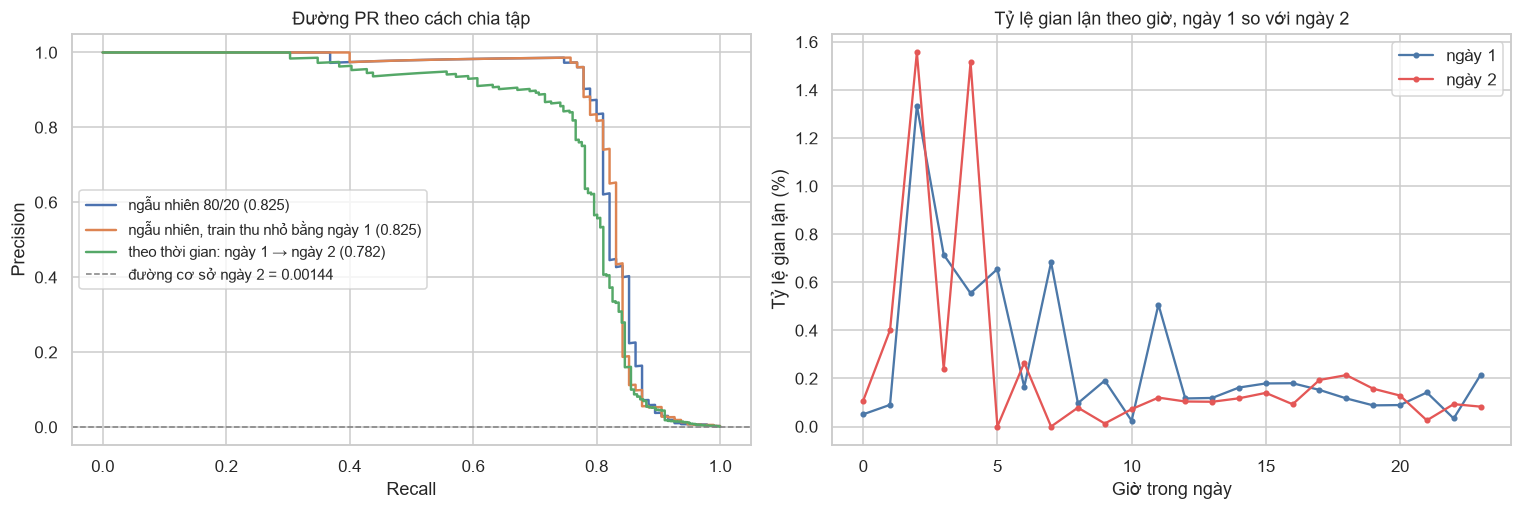

In [16]:
fig, truc = plt.subplots(1, 2, figsize=(14, 4.8))
for ten, (y_te, s) in diem_cach_chia.items():
    from sklearn.metrics import precision_recall_curve
    p, r, _ = precision_recall_curve(y_te, s)
    truc[0].plot(r, p, lw=1.6, label=f"{ten} ({average_precision_score(y_te, s):.3f})")
truc[0].axhline(baseline_pr_auc(y_n2), ls="--", c="grey", lw=1,
                label=f"đường cơ sở ngày 2 = {baseline_pr_auc(y_n2):.5f}")
truc[0].set_xlabel("Recall")
truc[0].set_ylabel("Precision")
truc[0].set_title("Đường PR theo cách chia tập")
truc[0].legend(fontsize="small")

# Tỷ lệ gian lận theo giờ của hai ngày — hình dạng của độ lệch thời gian
gio = pd.DataFrame({"gio": (df["Time"] % SECONDS_PER_DAY // 3600).astype(int),
                    "ngay": np.where(df["Time"] < SECONDS_PER_DAY, "ngày 1", "ngày 2"),
                    TARGET: df[TARGET]})
ty_le = gio.groupby(["gio", "ngay"])[TARGET].mean().unstack() * 100
ty_le.plot(ax=truc[1], marker="o", ms=3, color=["#4C78A8", "#E45756"])
truc[1].set_xlabel("Giờ trong ngày")
truc[1].set_ylabel("Tỷ lệ gian lận (%)")
truc[1].set_title("Tỷ lệ gian lận theo giờ, ngày 1 so với ngày 2")
truc[1].legend(title=None)
fig.tight_layout()
plots.save_fig(fig, "05_temporal_split.png")
plt.show()

**Nhận xét T-27 — chia theo thời gian thấp hơn, và lý do là độ lệch thời gian chứ không phải
thiếu dữ liệu.**

| Cách chia | PR-AUC test [KTC] | Recall@τ\* | Precision@τ\* | TP / FP / FN |
|---|---|---|---|---|
| ngẫu nhiên 80/20 | 0,825 [0,747 – 0,896] | 0,811 | 0,670 | 77 / 38 / 18 |
| ngẫu nhiên, train thu nhỏ bằng ngày 1 | 0,825 [0,749 – 0,896] | 0,800 | 0,826 | 76 / 16 / 19 |
| theo thời gian: ngày 1 → ngày 2 | **0,782** [0,728 – 0,836] | 0,836 | **0,332** | 168 / 338 / 33 |

**1. Phần chênh PR-AUC gần như toàn bộ do thời gian.** Tổng chênh là −0,044. Bớt dữ liệu huấn
luyện từ 226.980 xuống 144.236 dòng (đối chứng) chỉ làm mất −0,0004; phần −0,043 còn lại xuất
hiện khi tập kiểm thử là **một ngày khác**. Nếu không có dòng đối chứng thì không thể tách hai
nguyên nhân này ra — và giải thích dễ dãi "vì ít dữ liệu hơn" sẽ sai.

**2. Nhưng phải nói cẩn thận: khoảng tin cậy PR-AUC hai bên chồng lấn nhau** ([0,747 – 0,896] và
[0,728 – 0,836]). Hai tập kiểm thử khác nhau nên không làm được bootstrap theo cặp. Riêng PR-AUC
thì chỉ nói được "có xu hướng thấp hơn".

**3. Tín hiệu chắc chắn nằm ở precision tại ngưỡng cố định:** 0,670 [0,600 – 0,752] xuống 0,332
[0,305 – 0,359], hai khoảng tin cậy **tách hẳn nhau**. τ\* chọn trên ngày 1 là 0,0233, gần như
trùng với cách chia ngẫu nhiên (0,0232), vậy mà ở ngày 2 tỷ lệ báo động giả trên giao dịch hợp lệ
là 0,24% so với 0,067% — **gấp 3,6 lần**. Có hai nguyên nhân cộng dồn:

- **Tỷ lệ gian lận giảm** từ 0,189% (ngày 1) xuống 0,144% (ngày 2), tức −24%. Cùng một mô hình,
  cùng recall, ít mẫu dương hơn thì precision tự động giảm.
- **Phân bố của giao dịch hợp lệ dịch chuyển:** mô hình chấm nhiều giao dịch hợp lệ của ngày 2
  cao hơn ngưỡng, dù ngưỡng đó vừa khít với ngày 1. Hình tỷ lệ gian lận theo giờ ở trên cho thấy
  hai ngày khác hình dạng (tương quan giữa hai đường chỉ 0,62; lúc 11h là 0,51% ở ngày 1 so với
  0,12% ở ngày 2; lúc 5h và 7h ngày 2 không có vụ nào), và trung vị `Amount` của gian lận cũng
  đổi từ 11,85 xuống 8,90.

**4. Vì sao cách chia theo thời gian đáng tin hơn.** Chia ngẫu nhiên cho mô hình "xem trước"
chính ngày mà nó bị chấm: các giao dịch của cùng một đợt gian lận (nếu có) rải đều vào cả hai tập.
Triển khai thật không bao giờ có điều đó. PR-AUC out-of-fold trên ngày 1 là 0,877 — **cao nhất
trong ba cách chia** — nhưng khi chuyển sang ngày 2 thì mất 0,096, gấp 3,4 lần mức mất ở cách chia
ngẫu nhiên (0,028). Khoảng cách OOF → test đó chính là thước đo độ lệch thời gian.

**Hệ quả cho các giai đoạn sau:** (1) báo cáo phải nêu cả hai con số, và nói rằng 0,825 là **cận
trên lạc quan** của hiệu năng khi triển khai; (2) ngưỡng chọn một lần rồi để yên sẽ trôi — ở ngày
thứ hai, cùng τ\* đã sinh gấp 3,6 lần báo động giả. Đây là lý lẽ cho việc UI-03 cho phép chỉnh
ngưỡng lúc chạy, và cho phần hạn chế "dữ liệu chỉ hai ngày" (AC-D2).

---
## 6. Rà soát rò rỉ dữ liệu — T-28

Danh sách kiểm ở [08 §3.1](../docs/08-ke-hoach-kiem-thu.md) có 7 ô. Đọc lại mã một lần chỉ đúng ở
thời điểm đọc, nên cả 7 ô được viết thành kiểm thử trong `tests/test_no_leakage.py` — phần lớn là
quét mã nguồn trong `src/`, `scripts/`, `app.py` và các ô code của mọi notebook. Sửa mã về sau mà
phạm một ô thì `pytest` đỏ ngay.

| Ô | Nội dung | Kiểm thử |
|---|---|---|
| 1 | `fit_resample` chỉ nằm trong pipeline | `test_leak_1_…` + TC-20 |
| 2 | chia tập **trước** mọi lấy mẫu lại / huấn luyện | `test_leak_2_and_6_…` (notebook 03, 04, 05) |
| 3 | không `scaler.fit(X)` trên toàn bộ dữ liệu | `test_leak_3_…` + TC-21 |
| 4 | mọi CV là `StratifiedKFold` | `test_leak_4_…`, `test_leak_7_search_…` |
| 5 | ngưỡng chọn trên OOF / train, không trên test | `test_leak_5_…` |
| 6 | loại trùng lặp **trước** khi chia | `test_leak_2_and_6_…`, `test_leak_6_…` + TC-23 |
| 7 | `random_state=42` ở mọi đối tượng | `test_leak_7_…` (quét mã + duyệt tham số mọi pipeline) |

Ô dưới chạy lại đúng tệp kiểm thử đó từ notebook.

In [17]:
ket_qua = subprocess.run(
    # pytest.ini đã có addopts = -q; thêm -q nữa thành -qq và mất dòng tổng kết
    [sys.executable, "-m", "pytest", "tests/test_no_leakage.py", "--color=no", "-p", "no:cacheprovider"],
    cwd=ROOT, capture_output=True, text=True, encoding="utf-8", errors="replace",
)
print(ket_qua.stdout.strip().splitlines()[-1])
assert ket_qua.returncode == 0, ket_qua.stdout[-3000:]

57 passed in 14.69s


In [18]:
# Kiểm tra tính hợp lý của kết quả (08 §3.3) trên chính các con số của notebook này
kiem = {
    "PR-AUC test ≤ 0,95": chon["PR-AUC"] <= 0.95,
    "không có cặp Recall = 1,00 và Precision > 0,9": not (chon["recall"] == 1.0 and chon["precision"] > 0.9),
    "PR-AUC test nằm gần PR-AUC out-of-fold (chênh < 0,1)":
        abs(chon["PR-AUC"] - average_precision_score(y_train, OOF_CHON)) < 0.1,
    "chia theo thời gian KHÔNG cao hơn chia ngẫu nhiên một cách đáng ngờ":
        thoi_gian <= ngau_nhien + 0.05,
    "train và test không chung chỉ mục": not set(X_train_tho.index) & set(X_test_tho.index),
    "train và test không chung dòng nào theo giá trị":
        pd.merge(X_train_tho, X_test_tho, how="inner").empty,
}
for dieu, dat in kiem.items():
    print(f"[{'x' if dat else ' '}] {dieu}")
assert all(kiem.values())

[x] PR-AUC test ≤ 0,95
[x] không có cặp Recall = 1,00 và Precision > 0,9
[x] PR-AUC test nằm gần PR-AUC out-of-fold (chênh < 0,1)
[x] chia theo thời gian KHÔNG cao hơn chia ngẫu nhiên một cách đáng ngờ
[x] train và test không chung chỉ mục
[x] train và test không chung dòng nào theo giá trị


**Nhận xét T-28 — 7/7 ô của danh sách kiểm được tick, `test_no_leakage.py` xanh (AC-M4).**

Khi viết kiểm thử cho ô 7, lần quét mã phát hiện đúng **một** vi phạm: `app.py` lấy mẫu dữ liệu
demo với `random_state=0`. Không ảnh hưởng tới kết quả mô hình (đó là bảng giao dịch mẫu cho giao
diện Streamlit cũ), nhưng đã sửa về `RANDOM_STATE` để ô 7 đúng tuyệt đối và kiểm thử canh được
về sau.

Ngoài bảy ô, các con số của chính notebook này qua đủ phép kiểm tính hợp lý ở 08 §3.3: PR-AUC
0,825 nằm xa ngưỡng báo động 0,95, test gần với out-of-fold, và cách chia theo thời gian cho kết
quả **thấp hơn** — đúng chiều kỳ vọng của một pipeline không rò rỉ. Đặc trưng chỉ dùng giờ
trong ngày (`hour_sin`, `hour_cos`), không dùng `Time` tuyệt đối, nên mô hình không thể nhận ra
"ngày nào" để lợi dụng.

---
## 7. Tổng kết giai đoạn 4

| Việc | Kết quả | Trạng thái |
|---|---|---|
| T-24 | 30 lần thử, 19,8 phút. Cấu hình đầu 0,8538 ± 0,0328, **không hơn** cấu hình mặc định 0,8549; năm cấu hình đầu cách nhau 0,0008 | ✅ |
| T-25 | chọn cấu hình **mặc định** (hiệu OOF chứa 0). PR-AUC test **0,825**, Recall@τ\* **0,811** (77/95) | ✅ AC-M1, AC-M2 |
| T-26 | bootstrap 1.000 lần cho PR-AUC, ROC-AUC, Recall, Precision, F1 → `reports/final_test_metrics.csv` | ✅ AC-M6 |
| T-27 | theo thời gian 0,782 so với ngẫu nhiên 0,825; đối chứng cho thấy −0,043 do thời gian, −0,0004 do lượng dữ liệu; precision@τ\* 0,670 → 0,332 | ✅ AC-M7 |
| T-28 | 7/7 ô thành kiểm thử tự động; sửa `random_state=0` trong `app.py` | ✅ AC-M4 |

**Mang sang giai đoạn 5:**

- Mô hình cho notebook 06–08: `build_pipeline("xgboost", "class_weight", y=y_train)` với cấu hình
  mặc định, τ\* chi phí = 0,0232 trên out-of-fold.
- Cận dưới khoảng tin cậy của PR-AUC và recall đều sát 0,75 — không được viết "đạt chắc chắn".
- Ngưỡng trôi theo thời gian (FP ×3,6 ở ngày 2) là đầu vào cho phần phân tích độ nhạy T-31 và
  phần hạn chế của báo cáo.
- XGBoost cho điểm lệch nhẹ theo số luồng CPU. Trên cùng máy thì tái lập tuyệt đối; T-38 cần ghi
  số lõi của máy chạy.